<a href="https://colab.research.google.com/github/mariumijay/Road-Damage-Detection/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────
import os
import random
import warnings
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Numerical ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image processing ──────────────────────────────────────────────────────
import cv2
from PIL import Image

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style('whitegrid')

# ── ML utilities ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# ── Deep learning — TensorFlow / Keras ────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ Keras version      : {tf.keras.__version__}')
print(f'✅ GPU devices        : {tf.config.list_physical_devices("GPU")}')
print(f'✅ OpenCV version     : {cv2.__version__}')


✅ TensorFlow version : 2.19.0
✅ Keras version      : 3.13.2
✅ GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ OpenCV version     : 4.13.0


In [ ]:
# ── Step 1: Download dataset via kagglehub ────────────────────────────────
# Uncomment the lines below to download the dataset automatically.
# !pip install kagglehub -q

import kagglehub
kaggle_path = kagglehub.dataset_download('alaagaberh/rdd2022')
print(f'Dataset root : {kaggle_path}')

# ── Step 2: Point to the images root ──────────────────────────────────────
# Adjust DATASET_ROOT if your local path differs.
DATASET_ROOT  = os.path.join(kaggle_path, 'Dataset')
IMAGES_ROOT   = os.path.join(DATASET_ROOT, 'images')
LABELS_ROOT   = os.path.join(DATASET_ROOT, 'labels')

print(f'Images root  : {IMAGES_ROOT}')
print(f'Labels root  : {LABELS_ROOT}')
print(f'Splits found : {os.listdir(IMAGES_ROOT)}')


Using Colab cache for faster access to the 'rdd2022' dataset.
Dataset root : /kaggle/input/rdd2022
Images root  : /kaggle/input/rdd2022/Dataset/images
Labels root  : /kaggle/input/rdd2022/Dataset/labels
Splits found : ['val', 'test', 'train']


In [ ]:
# ── Global constants ──────────────────────────────────────────────────────
IMG_SIZE    = 96         # resize all images to 224×224
BATCH_SIZE  = 8
EPOCHS      = 30
LR          = 1e-3
NUM_CLASSES = 5
VALID_EXT   = ('.jpg', '.jpeg', '.png')

CLASS_NAMES = [
    'Longitudinal_Crack',   # 0  ←  D00
    'Transverse_Crack',     # 1  ←  D10
    'Alligator_Crack',      # 2  ←  D20
    'Pothole',              # 3  ←  D40
    'Normal_Road',          # 4  ←  no annotation
]

# Colour palette for visualisations (one colour per class)
CLASS_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

print('Class → Index mapping:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i}]  {name}')


Class → Index mapping:
  [0]  Longitudinal_Crack
  [1]  Transverse_Crack
  [2]  Alligator_Crack
  [3]  Pothole
  [4]  Normal_Road


In [ ]:
# ── Label parser: YOLO .txt  →  dominant class index ──────────────────────
def parse_label_txt(txt_path: str) -> int:
    """
    Read a YOLO-format annotation file and return the dominant class index.

    YOLO line: <class_id> <x_center> <y_center> <width> <height>

    Strategy:
      - Collect all valid class_ids from every bounding-box line.
      - Return the most frequent class_id (dominant damage type).
      - Return 4 (Normal_Road) when:
            * File does not exist  (unannotated image)
            * File is empty        (explicitly no damage)
            * All lines are malformed or out-of-range

    Args:
        txt_path: Full path to the .txt annotation file.

    Returns:
        Integer class index in range [0, 4].
    """
    if not os.path.isfile(txt_path):
        return 4   # No annotation file → Normal Road

    class_ids = []
    with open(txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                cls_id = int(line.split()[0])
                if 0 <= cls_id <= 3:   # valid damage class ids
                    class_ids.append(cls_id)
            except (ValueError, IndexError):
                continue

    if not class_ids:
        return 4   # Empty / no valid damage codes → Normal Road

    return Counter(class_ids).most_common(1)[0][0]


# ── Walk dataset and collect (image_path, label) pairs ─────────────────────
image_paths      = []
labels           = []
per_class_counts = defaultdict(int)

print('Scanning dataset ...')
print('=' * 55)

for dirpath, _, filenames in os.walk(IMAGES_ROOT):
    for fname in sorted(filenames):
        if not fname.lower().endswith(VALID_EXT):
            continue

        img_path = os.path.join(dirpath, fname)

        # Map image path → annotation path
        # e.g.  .../images/train/foo.jpg  →  .../labels/train/foo.txt
        rel       = os.path.relpath(img_path, IMAGES_ROOT)  # train/foo.jpg
        txt_path  = os.path.join(LABELS_ROOT,
                                  os.path.splitext(rel)[0] + '.txt')

        label = parse_label_txt(txt_path)
        image_paths.append(img_path)
        labels.append(label)
        per_class_counts[CLASS_NAMES[label]] += 1

labels = np.array(labels)
print(f'  Total images found : {len(image_paths):,}')
print()
print(f"{'Class':<25} {'Count':>8}   {'%':>6}")
print('-' * 45)
for cls in CLASS_NAMES:
    cnt = per_class_counts[cls]
    pct = cnt / len(image_paths) * 100
    print(f'{cls:<25} {cnt:>8,}   {pct:>5.1f}%')
print('-' * 45)
print(f"{'TOTAL':<25} {len(image_paths):>8,}   100.0%")


Scanning dataset ...
  Total images found : 58,239

Class                        Count        %
---------------------------------------------
Longitudinal_Crack          18,002    30.9%
Transverse_Crack             8,668    14.9%
Alligator_Crack             13,860    23.8%
Pothole                     11,697    20.1%
Normal_Road                  6,012    10.3%
---------------------------------------------
TOTAL                       58,239   100.0%


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np

# ── Image loader & preprocessor ──────────────────────────────────────────
def load_and_preprocess(img_path: str, img_size: int = IMG_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    return img


# ── Generator function (loads images batch by batch) ─────────────────────
def data_generator(image_paths, labels, batch_size=16):
    n = len(image_paths)

    while True:
        for i in range(0, n, batch_size):

            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            images = [load_and_preprocess(p) for p in batch_paths]
            images = np.array(images, dtype=np.float32)

            yield images, np.array(batch_labels)


# ── Create generator ─────────────────────────────────────────────────────
BATCH_SIZE = 16

train_gen = data_generator(image_paths, labels, batch_size=BATCH_SIZE)

print("✅ Generator created. Images will now load batch-by-batch instead of filling RAM.")

✅ Generator created. Images will now load batch-by-batch instead of filling RAM.


In [ ]:
# ── Stratified train / val / test split on PATHS (no X array needed) ──────
from sklearn.model_selection import train_test_split
import numpy as np

labels = np.array(labels)           # make sure it's a numpy array

# Step 1 : 70 % train  |  30 % temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels,
    test_size    = 0.30,
    random_state = SEED,
    stratify     = labels
)

# Step 2 : 15 % val  |  15 % test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size    = 0.50,
    random_state = SEED,
    stratify     = temp_labels
)

print(f"Train : {len(train_paths):,} images")
print(f"Val   : {len(val_paths):,}   images")
print(f"Test  : {len(test_paths):,}  images")


Train : 40,767 images
Val   : 8,736   images
Test  : 8,736  images


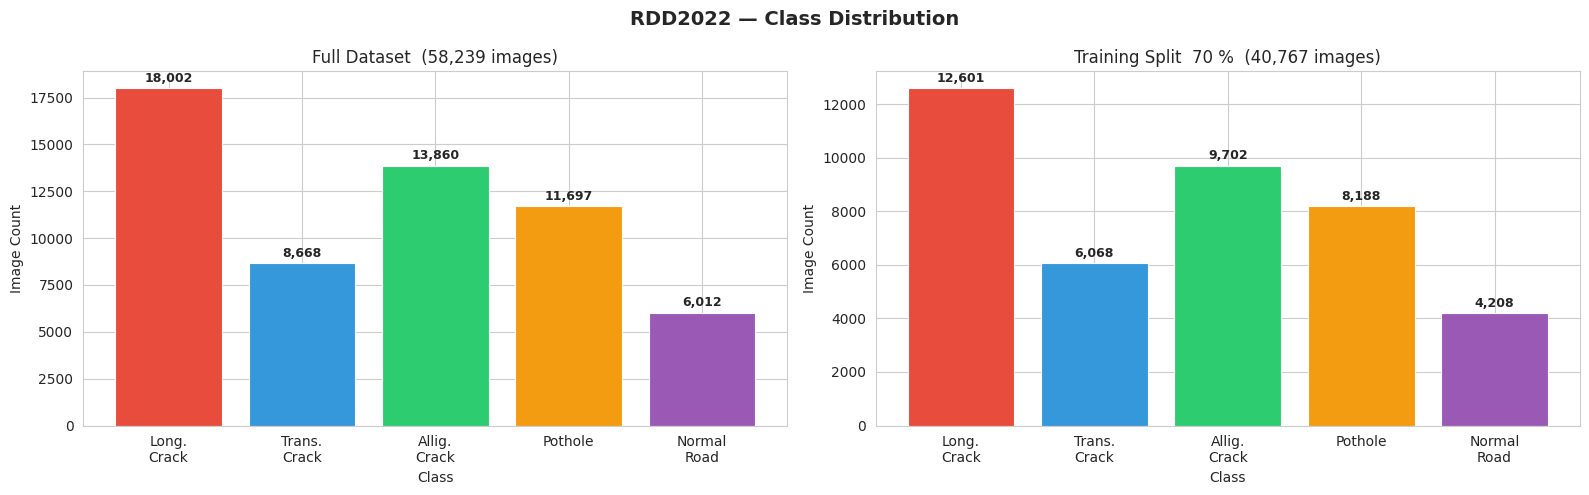


📊 Class distribution plotted.

Class                         Full     Train       Val      Test
------------------------------------------------------------
Longitudinal_Crack          18,002    12,601     2,700     2,701
Transverse_Crack             8,668     6,068     1,300     1,300
Alligator_Crack             13,860     9,702     2,079     2,079
Pothole                     11,697     8,188     1,755     1,754
Normal_Road                  6,012     4,208       902       902
------------------------------------------------------------
TOTAL                       58,239    40,767     8,736     8,736


In [ ]:
# ── Plot 1 : Class distribution bar chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('RDD2022 — Class Distribution', fontsize=14, fontweight='bold')

short_names = ['Long.\nCrack', 'Trans.\nCrack', 'Allig.\nCrack', 'Pothole', 'Normal\nRoad']

# ── Left : Full dataset (from image_paths + labels) ───────────────────────
counts_all = [int(np.sum(labels == i)) for i in range(NUM_CLASSES)]

bars = axes[0].bar(short_names, counts_all,
                   color=CLASS_COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title(f'Full Dataset  ({len(image_paths):,} images)', fontsize=12)
axes[0].set_ylabel('Image Count')
axes[0].set_xlabel('Class')
for bar, count in zip(bars, counts_all):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts_all) * 0.01,
                 f'{count:,}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# ── Right : Training split only (from train_labels) ───────────────────────
train_counts = [int(np.sum(train_labels == i)) for i in range(NUM_CLASSES)]

bars2 = axes[1].bar(short_names, train_counts,
                    color=CLASS_COLORS, edgecolor='white', linewidth=0.8)
axes[1].set_title(f'Training Split  70 %  ({len(train_paths):,} images)', fontsize=12)
axes[1].set_ylabel('Image Count')
axes[1].set_xlabel('Class')
for bar, count in zip(bars2, train_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(train_counts) * 0.01,
                 f'{count:,}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Console summary ────────────────────────────────────────────────────────
print('\n📊 Class distribution plotted.')
print(f"\n{'Class':<25} {'Full':>8}  {'Train':>8}  {'Val':>8}  {'Test':>8}")
print('-' * 60)
for i, cls in enumerate(CLASS_NAMES):
    f  = int(np.sum(labels       == i))
    tr = int(np.sum(train_labels == i))
    v  = int(np.sum(val_labels   == i))
    te = int(np.sum(test_labels  == i))
    print(f'{cls:<25} {f:>8,}  {tr:>8,}  {v:>8,}  {te:>8,}')
print('-' * 60)
print(f"{'TOTAL':<25} {len(labels):>8,}  {len(train_labels):>8,}  "
      f"{len(val_labels):>8,}  {len(test_labels):>8,}")

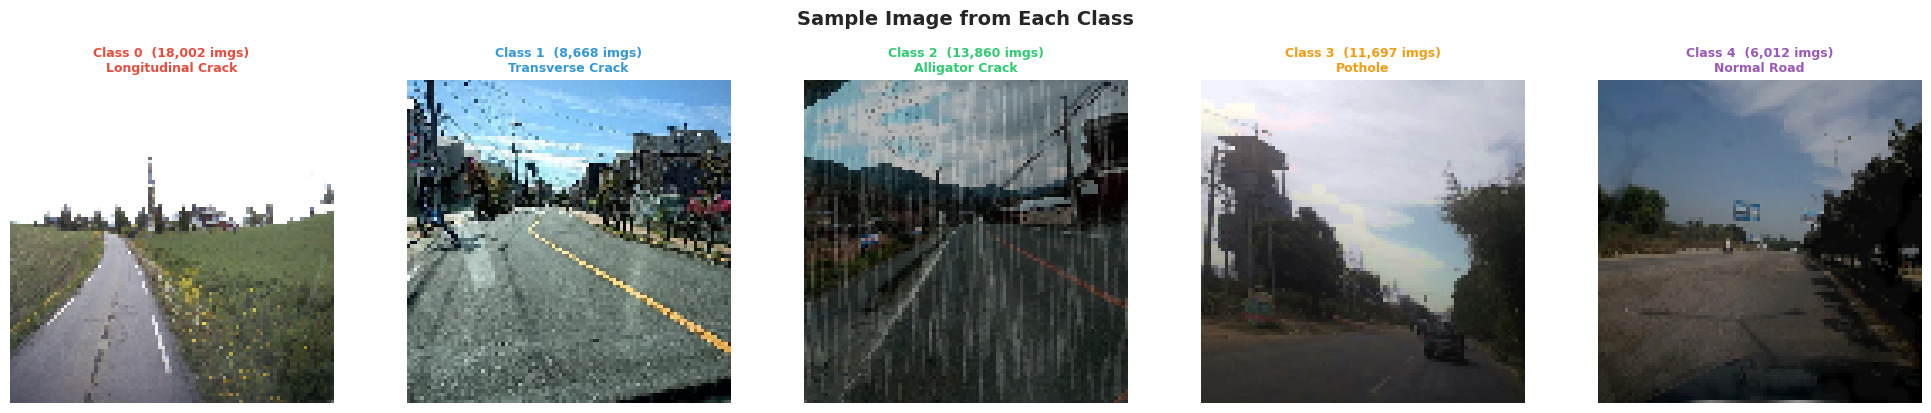


🖼️  Sample images displayed.


In [ ]:
# ── Plot 2 : Sample images (one per class) ────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
fig.suptitle('Sample Image from Each Class', fontsize=14, fontweight='bold', y=1.02)

for cls_idx in range(NUM_CLASSES):
    # Find indices belonging to this class directly from labels array
    indices = np.where(labels == cls_idx)[0]

    if len(indices) == 0:
        axes[cls_idx].axis('off')
        axes[cls_idx].set_title(
            f'Class {cls_idx}\nNo samples',
            fontsize=10, color='grey'
        )
        continue

    # Pick a random image path for this class
    sample_idx = random.choice(indices)
    sample_img = load_and_preprocess(image_paths[sample_idx])

    axes[cls_idx].imshow(sample_img)
    axes[cls_idx].set_title(
        f'Class {cls_idx}  ({int(np.sum(labels == cls_idx)):,} imgs)\n'
        f'{CLASS_NAMES[cls_idx].replace("_", " ")}',
        fontsize=9, color=CLASS_COLORS[cls_idx], fontweight='bold'
    )
    axes[cls_idx].axis('off')

    # Coloured border around each subplot
    for spine in axes[cls_idx].spines.values():
        spine.set_edgecolor(CLASS_COLORS[cls_idx])
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🖼️  Sample images displayed.')

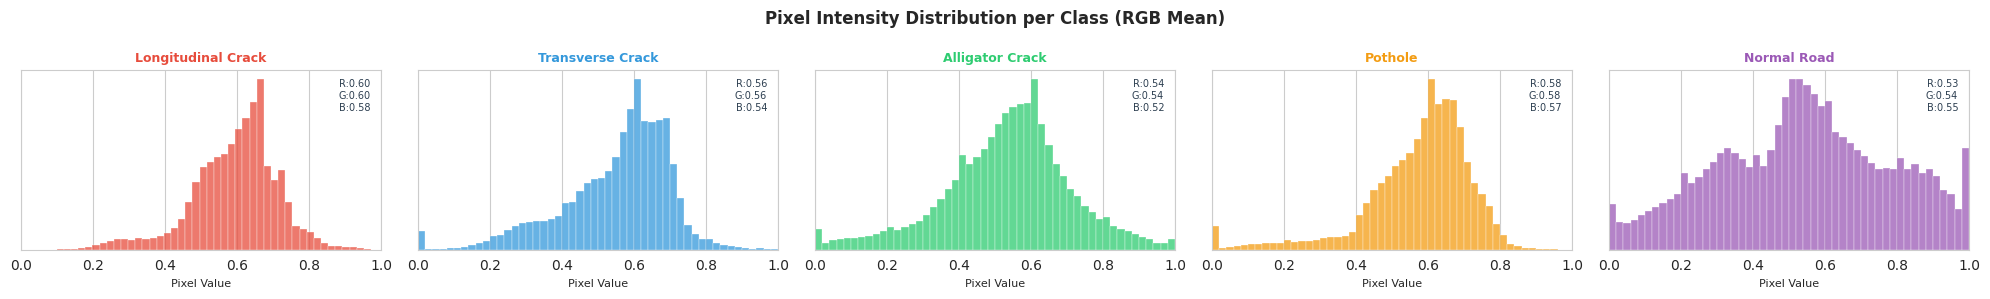


📈 Pixel intensity distributions plotted.


In [ ]:
# ── Plot 3 : Pixel intensity distribution ─────────────────────────────────
SAMPLES_PER_CLASS = 50   # images to sample per class for the histogram

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 3))
fig.suptitle('Pixel Intensity Distribution per Class (RGB Mean)',
             fontsize=12, fontweight='bold')

for cls_idx in range(NUM_CLASSES):
    # ── Get up to 50 image paths belonging to this class ──────────────────
    cls_indices = np.where(labels == cls_idx)[0][:SAMPLES_PER_CLASS]

    if len(cls_indices) == 0:
        axes[cls_idx].axis('off')
        continue

    # ── Load images on-the-fly from disk (no X_train needed) ──────────────
    cls_imgs = []
    for idx in cls_indices:
        img = load_and_preprocess(image_paths[idx])   # float32, [0,1]
        if img is not None:
            cls_imgs.append(img)

    if len(cls_imgs) == 0:
        axes[cls_idx].axis('off')
        continue

    cls_imgs  = np.array(cls_imgs, dtype=np.float32)  # (N, 224, 224, 3)
    mean_vals = cls_imgs.mean(axis=(0, 1, 2))          # [R_mean, G_mean, B_mean]
    pixels    = cls_imgs.flatten()                     # all pixel values

    # ── Plot histogram ────────────────────────────────────────────────────
    axes[cls_idx].hist(pixels, bins=50,
                       color=CLASS_COLORS[cls_idx],
                       alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[cls_idx].set_title(
        CLASS_NAMES[cls_idx].replace('_', ' '),
        fontsize=9, color=CLASS_COLORS[cls_idx], fontweight='bold'
    )
    axes[cls_idx].set_xlabel('Pixel Value', fontsize=8)
    axes[cls_idx].set_xlim(0, 1)
    axes[cls_idx].set_yticks([])

    # ── Annotate with RGB channel means ───────────────────────────────────
    axes[cls_idx].text(
        0.97, 0.95,
        f'R:{mean_vals[0]:.2f}\nG:{mean_vals[1]:.2f}\nB:{mean_vals[2]:.2f}',
        transform=axes[cls_idx].transAxes,
        fontsize=7, va='top', ha='right', color='#2C3E50',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6)
    )

plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📈 Pixel intensity distributions plotted.')

In [ ]:
# ── Training augmentation config ──────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    zoom_range         = 0.20,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

eval_datagen = ImageDataGenerator()   # no augmentation for val / test


# ── Core: on-the-fly batch generator from file paths ──────────────────────
def path_generator(img_paths, labels, datagen,
                   batch_size=BATCH_SIZE, num_classes=NUM_CLASSES,
                   shuffle=True, seed=SEED):
    """
    Yield (X_batch, y_batch) by reading images from disk batch-by-batch.

    - Applies the transforms defined in `datagen` (augmentation or identity).
    - Never loads the full dataset into RAM.
    - Loops forever as required by model.fit().

    Args:
        img_paths  : list of image file paths
        labels     : 1-D integer label array aligned with img_paths
        datagen    : ImageDataGenerator instance (with or without augmentation)
        batch_size : images per batch
        num_classes: number of output classes
        shuffle    : shuffle order at every epoch start
        seed       : reproducibility seed
    """
    rng     = np.random.default_rng(seed)
    indices = np.arange(len(img_paths))

    while True:                                     # loop forever for Keras
        if shuffle:
            rng.shuffle(indices)

        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start : start + batch_size]

            X_batch, y_batch = [], []
            for idx in batch_idx:
                img = load_and_preprocess(img_paths[idx])
                if img is None:                     # skip corrupt files
                    continue
                X_batch.append(img)
                y_batch.append(labels[idx])

            if len(X_batch) == 0:
                continue

            X_batch = np.array(X_batch, dtype=np.float32)  # (B, 224, 224, 3)
            y_batch = to_categorical(
                np.array(y_batch, dtype=np.int32), num_classes
            ).astype(np.float32)                            # (B, 5)

            # Apply ImageDataGenerator transforms batch-by-batch
            aug_iter = datagen.flow(
                X_batch, y_batch,
                batch_size = len(X_batch),
                shuffle    = False
            )
            X_aug, y_aug = next(aug_iter)

            yield X_aug, y_aug


# ── Build the three generators ────────────────────────────────────────────
train_generator = path_generator(
    train_paths, train_labels,
    datagen    = train_datagen,
    shuffle    = True,
    seed       = SEED
)
val_generator = path_generator(
    val_paths, val_labels,
    datagen    = eval_datagen,
    shuffle    = False
)
test_generator = path_generator(
    test_paths, test_labels,
    datagen    = eval_datagen,
    shuffle    = False
)

# ── Steps per epoch (required by model.fit) ───────────────────────────────
train_steps = max(1, len(train_paths) // BATCH_SIZE)
val_steps   = max(1, len(val_paths)   // BATCH_SIZE)
test_steps  = max(1, len(test_paths)  // BATCH_SIZE)

print('✅ Generators created:')
print(f'   Train  → {len(train_paths):,} images  |  {train_steps} steps/epoch')
print(f'   Val    → {len(val_paths):,}   images  |  {val_steps}  steps')
print(f'   Test   → {len(test_paths):,}  images  |  {test_steps} steps')

✅ Generators created:
   Train  → 40,767 images  |  5095 steps/epoch
   Val    → 8,736   images  |  1092  steps
   Test   → 8,736  images  |  1092 steps


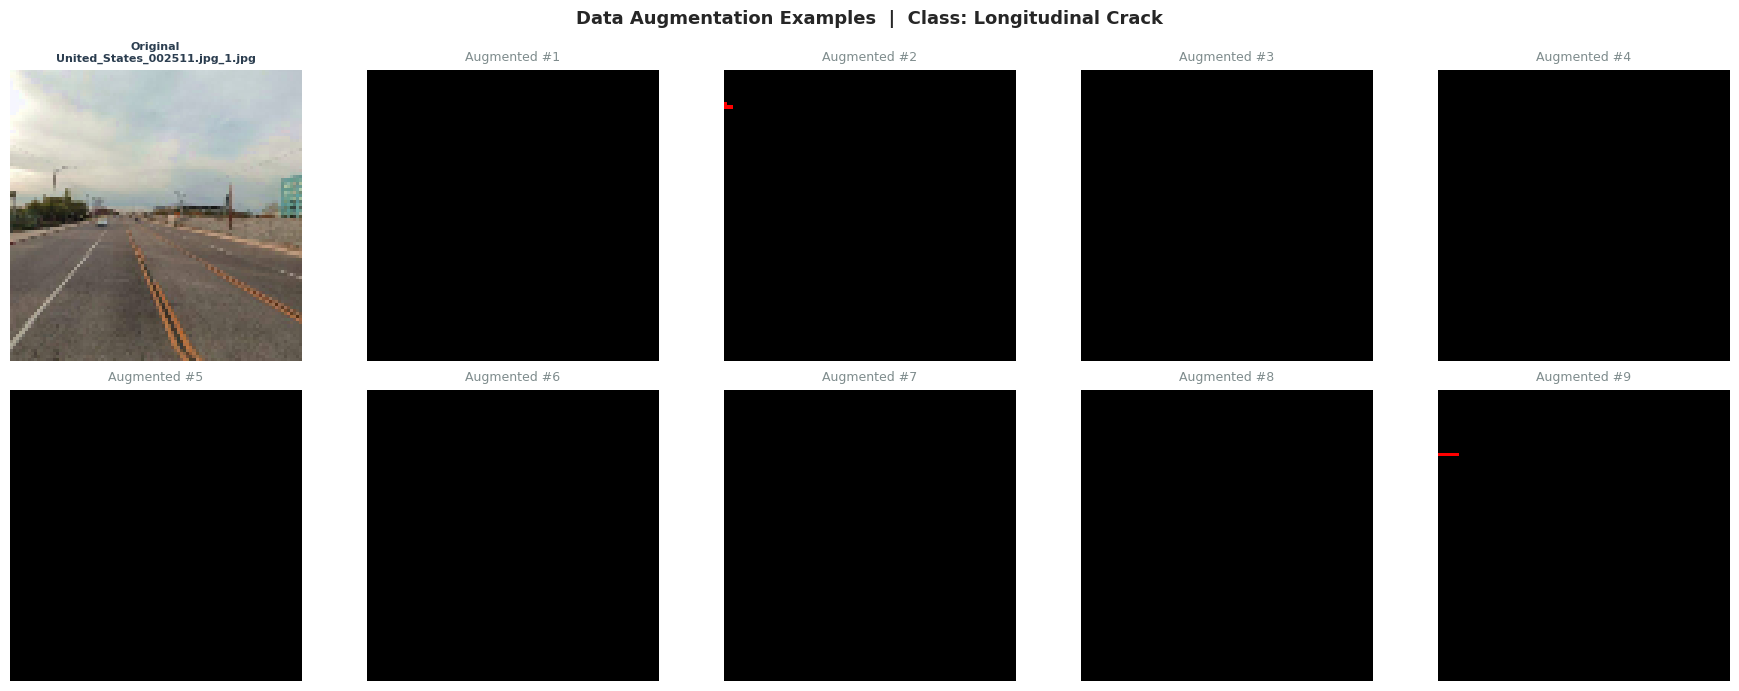


🔄 Augmentation examples visualised.
   Source image : /kaggle/input/rdd2022/Dataset/images/train/United_States_002511.jpg_1.jpg
   Class        : [0] Longitudinal_Crack


In [ ]:
# ── Visualise augmented samples (original + 9 augmented versions) ─────────

# Pick the first training image path and load it
sample_path  = train_paths[0]
sample_label = train_labels[0]
sample_img   = load_and_preprocess(sample_path)          # (224, 224, 3)

# Expand to batch shape for datagen.flow()
sample_batch = np.expand_dims(sample_img, axis=0)        # (1, 224, 224, 3)
sample_lbl   = to_categorical([sample_label], NUM_CLASSES).astype(np.float32)

# Create a single-image augmentation generator
aug_gen = train_datagen.flow(
    sample_batch, sample_lbl,
    batch_size = 1,
    seed       = SEED
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(
    f'Data Augmentation Examples  |  Class: {CLASS_NAMES[sample_label].replace("_", " ")}',
    fontsize=13, fontweight='bold'
)

# ── Original image (top-left) ──────────────────────────────────────────────
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title(
    f'Original\n{os.path.basename(sample_path)}',
    fontsize=8, fontweight='bold', color='#2C3E50'
)
axes[0, 0].axis('off')

# ── 9 augmented versions ───────────────────────────────────────────────────
for i, ax in enumerate(axes.flatten()[1:]):
    aug_batch, _ = next(aug_gen)
    ax.imshow(np.clip(aug_batch[0], 0, 1))
    ax.set_title(f'Augmented #{i + 1}', fontsize=9, color='#7F8C8D')
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🔄 Augmentation examples visualised.')
print(f'   Source image : {sample_path}')
print(f'   Class        : [{sample_label}] {CLASS_NAMES[sample_label]}')

In [ ]:
# ── Verify input shape from a real loaded image ────────────────────────────
sample_check = load_and_preprocess(train_paths[0])
INPUT_SHAPE  = sample_check.shape                  # (224, 224, 3)
print(f'✅ Input shape confirmed from disk: {INPUT_SHAPE}')
del sample_check                                   # free memory


def build_cnn(
    input_shape : tuple = INPUT_SHAPE,
    num_classes : int   = NUM_CLASSES
) -> tf.keras.Model:
    """
    Build and return the custom CNN for road damage classification.

    Architecture: 4 convolutional blocks followed by a dense classifier head.

    Args:
        input_shape : (H, W, C) tuple — verified from actual loaded image.
        num_classes : Number of output classes.

    Returns:
        Uncompiled tf.keras.Sequential model.
    """
    model = Sequential(name='RoadDamage_CNN')
    model.add(Input(shape=input_shape))

    # ── Block 1 : 32 filters ──────────────────────────────────────────────
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1'))
    model.add(BatchNormalization(name='bn1'))
    model.add(MaxPooling2D((2, 2), name='pool1'))            # 224→112

    # ── Block 2 : 64 filters ──────────────────────────────────────────────
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'))
    model.add(BatchNormalization(name='bn2'))
    model.add(MaxPooling2D((2, 2), name='pool2'))            # 112→56
    model.add(Dropout(0.25, name='drop2'))

    # ── Block 3 : 128 filters ─────────────────────────────────────────────
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3'))
    model.add(BatchNormalization(name='bn3'))
    model.add(MaxPooling2D((2, 2), name='pool3'))            # 56→28
    model.add(Dropout(0.25, name='drop3'))

    # ── Block 4 : 256 filters ─────────────────────────────────────────────
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu', name='conv4'))
    model.add(BatchNormalization(name='bn4'))
    model.add(MaxPooling2D((2, 2), name='pool4'))            # 28→14
    model.add(Dropout(0.30, name='drop4'))

    # ── Classifier head ───────────────────────────────────────────────────
    model.add(Flatten(name='flatten'))

    model.add(Dense(512, activation='relu', name='dense1'))
    model.add(BatchNormalization(name='bn5'))
    model.add(Dropout(0.50, name='drop5'))

    model.add(Dense(256, activation='relu', name='dense2'))
    model.add(Dropout(0.40, name='drop6'))

    model.add(Dense(num_classes, activation='softmax', name='output'))

    return model


# ── Instantiate & summarise ───────────────────────────────────────────────
model = build_cnn()
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\n📐 Input shape          : {INPUT_SHAPE}')
print(f'📐 Total parameters     : {total_params:,}')
print(f'📐 Trainable parameters : {trainable_params:,}')
print(f'📐 Training on          : {len(train_paths):,} images  ({len(train_paths)//BATCH_SIZE} steps/epoch)')

✅ Input shape confirmed from disk: (96, 96, 3)


Model: "RoadDamage_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,244,101 (20.00 MB)

 Trainable params: 5,242,117 (20.00 MB)

 Non-trainable params: 1,984 (7.75 KB)


📐 Input shape          : (96, 96, 3)
📐 Total parameters     : 5,244,101
📐 Trainable parameters : 5,242,117
📐 Training on          : 40,767 images  (5095 steps/epoch)


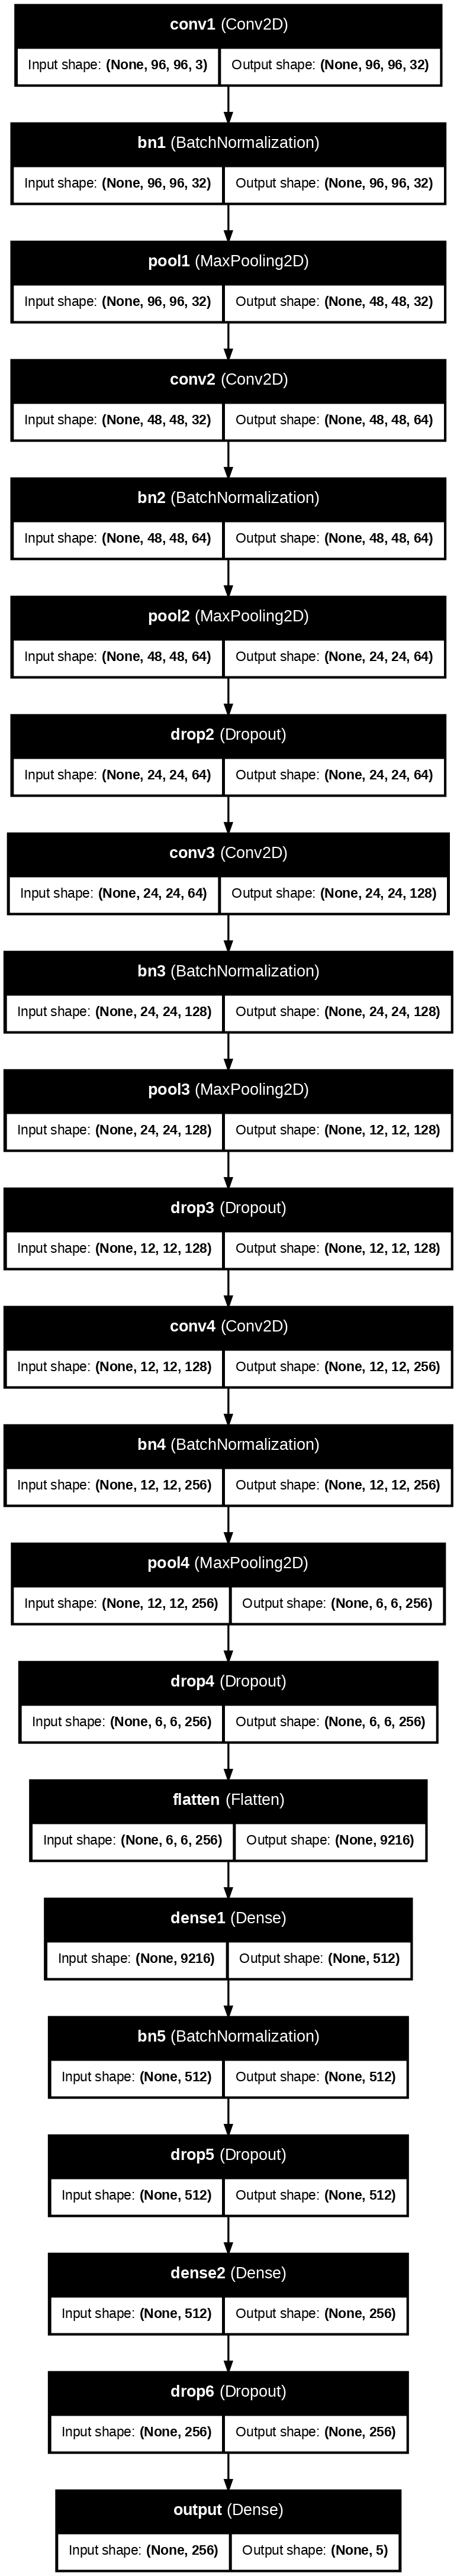

✅ Architecture diagram saved to model_architecture.png


In [ ]:
# ── Optional: save architecture diagram ───────────────────────────────────
# Requires pydot + graphviz: !pip install pydot graphviz
try:
    plot_model(
        model,
        to_file        = 'model_architecture.png',
        show_shapes    = True,
        show_layer_names = True,
        rankdir        = 'TB',
        dpi            = 120
    )
    from IPython.display import Image as IPImage
    display(IPImage('model_architecture.png'))
    print('✅ Architecture diagram saved to model_architecture.png')
except Exception as e:
    print(f'ℹ️  Architecture diagram skipped ({e})')
    print('   Install pydot and graphviz to enable this feature.')


In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────
model.compile(
    optimizer = Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print('✅ Model compiled.')
print(f'   Optimizer : Adam  (initial lr = {LR})')
print(f'   Loss      : categorical_crossentropy')
print(f'   Metrics   : accuracy')

# ── Callbacks ─────────────────────────────────────────────────────────────
CHECKPOINT_PATH = 'best_road_damage_model.keras'

callbacks = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 4,
        min_lr    = 1e-7,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath         = CHECKPOINT_PATH,
        monitor          = 'val_accuracy',
        save_best_only   = True,
        save_weights_only= False,
        verbose          = 1
    )
]

print('\n✅ Callbacks configured:')
for cb in callbacks:
    print(f'   • {cb.__class__.__name__}')


✅ Model compiled.
   Optimizer : Adam  (initial lr = 0.001)
   Loss      : categorical_crossentropy
   Metrics   : accuracy

✅ Callbacks configured:
   • EarlyStopping
   • ReduceLROnPlateau
   • ModelCheckpoint


In [ ]:
# ── Compute steps per epoch (from path lengths, not arrays) ───────────────
steps_per_epoch  = train_steps   # already computed: len(train_paths) // BATCH_SIZE
validation_steps = val_steps     # already computed: len(val_paths)   // BATCH_SIZE

print(f'Training on   {len(train_paths):,} images  |  {steps_per_epoch} steps/epoch')
print(f'Validating on {len(val_paths):,}   images  |  {validation_steps} steps')
print(f'Max epochs : {EPOCHS}  |  Batch size : {BATCH_SIZE}')
print('=' * 55)

# ── Train ─────────────────────────────────────────────────────────────────
history = model.fit(
    train_generator,
    steps_per_epoch  = steps_per_epoch,
    epochs           = EPOCHS,
    validation_data  = val_generator,
    validation_steps = validation_steps,
    callbacks        = callbacks,
    verbose          = 1
)

print('\n' + '=' * 55)
print('✅ Training complete!')
print(f'   Epochs trained    : {len(history.history["accuracy"])}')
print(f'   Best val accuracy : {max(history.history["val_accuracy"]):.4f}')
print(f'   Best val loss     : {min(history.history["val_loss"]):.4f}')

Training on   40,767 images  |  5095 steps/epoch
Validating on 8,736   images  |  1092 steps
Max epochs : 30  |  Batch size : 8
Epoch 1/30
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.2644 - loss: 1.8775
Epoch 1: val_accuracy improved from None to 0.30907, saving model to best_road_damage_model.keras

Epoch 1: finished saving model to best_road_damage_model.keras
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 763s 147ms/step - accuracy: 0.2819 - loss: 1.6764 - val_accuracy: 0.3091 - val_loss: 1.9489 - learning_rate: 0.0010
Epoch 2/30
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3034 - loss: 1.5538
Epoch 2: val_accuracy did not improve from 0.30907
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 601s 116ms/step - accuracy: 0.3037 - loss: 1.5525 - val_accuracy: 0.3091 - val_loss: 3.5568 - learning_rate: 0.0010
Epoch 3/30
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3041 - loss: 1.5470
Epoch 3: val_accuracy did not improve from 0.30907
5095/5095 ━━━━━━━━━━━━━━━━━━━━ 560s 110ms/step

In [ ]:
def plot_training_history(history: tf.keras.callbacks.History) -> None:
    """
    Plot training and validation accuracy and loss curves side-by-side.
    Annotates the best validation epoch and the early-stopping point.
    """
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    best_epoch = int(np.argmax(val_acc)) + 1   # 1-indexed
    last_epoch = len(acc)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Model Training History', fontsize=14, fontweight='bold')

    # ── Accuracy ──────────────────────────────────────────────────────────
    axes[0].plot(epochs_range, acc,     color='#3498DB', linewidth=2,
                 marker='o', markersize=4, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, color='#E74C3C', linewidth=2,
                 marker='s', markersize=4, label='Val Accuracy')
    axes[0].axvline(x=best_epoch, color='#2ECC71', linestyle='--',
                    linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    if last_epoch < EPOCHS:
        axes[0].axvline(x=last_epoch, color='#F39C12', linestyle=':',
                        linewidth=1.5, label=f'Early Stop (ep {last_epoch})')
    axes[0].set_title('Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.4)
    axes[0].annotate(
        f'{max(val_acc):.4f}',
        xy=(best_epoch, max(val_acc)),
        xytext=(best_epoch + 0.3, max(val_acc) - 0.05),
        fontsize=9, color='#E74C3C', fontweight='bold'
    )

    # ── Loss ──────────────────────────────────────────────────────────────
    axes[1].plot(epochs_range, loss,     color='#3498DB', linewidth=2,
                 marker='o', markersize=4, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, color='#E74C3C', linewidth=2,
                 marker='s', markersize=4, label='Val Loss')
    axes[1].axvline(x=best_epoch, color='#2ECC71', linestyle='--',
                    linewidth=1.5, label=f'Best Epoch ({best_epoch})')
    if last_epoch < EPOCHS:
        axes[1].axvline(x=last_epoch, color='#F39C12', linestyle=':',
                        linewidth=1.5, label=f'Early Stop (ep {last_epoch})')
    axes[1].set_title('Loss', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n📊 Training history saved → training_history.png')
    print(f'   Best val accuracy : {max(val_acc):.4f}  (epoch {best_epoch})')
    print(f'   Final train acc   : {acc[-1]:.4f}')
    print(f'   Overfit gap       : {acc[-1] - val_acc[-1]:.4f}')


plot_training_history(history)

In [ ]:
# ── Load best model saved by ModelCheckpoint ──────────────────────────────
print(f'Loading best model from: {CHECKPOINT_PATH}')
best_model = load_model(CHECKPOINT_PATH)
print('✅ Best model loaded.')

# ── Evaluate on test set using the path-based generator ───────────────────
test_loss, test_acc = best_model.evaluate(
    test_generator,
    steps   = test_steps,
    verbose = 1
)

print('\n' + '=' * 45)
print(f'  Test Images   : {len(test_paths):,}')
print(f'  Test Accuracy : {test_acc * 100:.2f} %')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 45)

In [ ]:
# ── Generate predictions from path-based generator ────────────────────────
print(f'Running predictions on {len(test_paths):,} test images ...')

y_pred_prob = best_model.predict(
    test_generator,
    steps   = test_steps,
    verbose = 1
)

y_pred = np.argmax(y_pred_prob, axis=1)   # predicted class indices
y_true = test_labels[:len(y_pred)]        # true integer labels (aligned to steps)

print(f'✅ Predictions shape : {y_pred_prob.shape}')
print(f'✅ y_pred unique     : {np.unique(y_pred)}')
print(f'✅ y_true unique     : {np.unique(y_true)}')

# ── Classification report ─────────────────────────────────────────────────
print('\n' + '=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
report = classification_report(
    y_true, y_pred,
    target_names = [c.replace('_', ' ') for c in CLASS_NAMES],
    digits       = 4
)
print(report)

# ── Metrics summary as DataFrame ──────────────────────────────────────────
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(NUM_CLASSES))
)
metrics_df = pd.DataFrame({
    'Class'    : [c.replace('_', ' ') for c in CLASS_NAMES],
    'Precision': np.round(precision, 4),
    'Recall'   : np.round(recall,    4),
    'F1-Score' : np.round(f1,        4),
    'Support'  : support
})

# Add macro & weighted averages
p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

macro_row    = pd.DataFrame([{'Class': 'Macro Avg',
                               'Precision': round(p_mac, 4),
                               'Recall'   : round(r_mac, 4),
                               'F1-Score' : round(f_mac, 4),
                               'Support'  : len(y_true)}])
weighted_row = pd.DataFrame([{'Class': 'Weighted Avg',
                               'Precision': round(p_wt, 4),
                               'Recall'   : round(r_wt, 4),
                               'F1-Score' : round(f_wt, 4),
                               'Support'  : len(y_true)}])

metrics_df = pd.concat([metrics_df, macro_row, weighted_row], ignore_index=True)
print(metrics_df.to_string(index=False))

In [ ]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────
def plot_confusion_matrix(
    y_true     : np.ndarray,
    y_pred     : np.ndarray,
    class_names: list
) -> None:
    """
    Plot a styled confusion matrix heatmap (raw counts + normalised).

    Args:
        y_true      : Ground-truth integer labels  (from test_labels).
        y_pred      : Predicted integer labels     (from best_model.predict).
        class_names : List of human-readable class names.
    """
    cm    = confusion_matrix(y_true, y_pred)
    short = [c.replace('_', '\n') for c in class_names]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')

    for ax, (data, title, fmt) in zip(
        axes,
        [
            (cm,
             f'Raw Counts  (n={len(y_true):,})', 'd'),
            (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis],
             'Normalised (row %)', '.2f')
        ]
    ):
        sns.heatmap(
            data,
            annot       = True,
            fmt         = fmt,
            cmap        = 'Blues',
            xticklabels = short,
            yticklabels = short,
            linewidths  = 0.5,
            linecolor   = 'white',
            cbar_kws    = {'shrink': 0.8},
            ax          = ax
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label',      fontsize=11)
        ax.tick_params(axis='both', labelsize=9)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n🧩 Confusion matrix saved → confusion_matrix.png')

    # ── Per-class diagonal accuracy ───────────────────────────────────────
    print(f'\n{"Class":<25}  {"Correct":>8}  {"Total":>8}  {"Accuracy":>9}')
    print('-' * 55)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    for i, cls in enumerate(class_names):
        print(f'  {cls:<23}  {cm[i,i]:>8,}  {cm[i].sum():>8,}  {cm_norm[i,i]*100:>8.1f} %')


# y_true and y_pred are already built in the previous cell
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

In [ ]:
# ── F1-Score bar chart per class ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

f1_vals    = f1.tolist()
short      = [c.replace('_', '\n') for c in CLASS_NAMES]
bars       = ax.bar(short, f1_vals, color=CLASS_COLORS,
                    edgecolor='white', linewidth=0.8, width=0.6)

for bar, val in zip(bars, f1_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.axhline(
    y=np.mean(f1_vals), color='#2C3E50',
    linestyle='--', linewidth=1.5,
    label=f'Macro F1 = {np.mean(f1_vals):.4f}'
)
ax.set_title('F1-Score per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('F1-Score')
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ F1 score chart saved → f1_scores.png')
print(f'\n{"Class":<25}  {"F1-Score":>9}')
print('-' * 37)
for cls, val in zip(CLASS_NAMES, f1_vals):
    bar = '█' * int(val * 20)
    print(f'  {cls:<23}  {val:.4f}  {bar}')
print('-' * 37)
print(f'  {"Macro Average":<23}  {np.mean(f1_vals):.4f}')

In [ ]:
# ── Grid of 15 sample predictions ─────────────────────────────────────────
def visualize_predictions(
    test_paths : list,
    y_true     : np.ndarray,
    y_pred     : np.ndarray,
    y_pred_prob: np.ndarray,
    class_names: list,
    n          : int = 15,
    seed       : int = SEED
) -> None:
    """
    Display n test images in a 3x5 grid with prediction details.
    Loads images on-the-fly from test_paths — no X_test array needed.

    Green title = correct prediction  |  Red title = incorrect prediction
    """
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(test_paths), n, replace=False)

    rows, cols = 3, 5
    fig, axes  = plt.subplots(rows, cols, figsize=(22, 14))
    fig.suptitle(
        'Predictions on Test Set   ✅ Green = Correct   ❌ Red = Wrong',
        fontsize=13, fontweight='bold', y=1.01
    )

    for ax, idx in zip(axes.flatten(), indices):
        # Load image from disk on-the-fly
        img        = load_and_preprocess(test_paths[idx])   # (224, 224, 3)
        pred_idx   = y_pred[idx]
        true_idx   = y_true[idx]
        confidence = y_pred_prob[idx][pred_idx] * 100
        is_correct = (pred_idx == true_idx)
        title_color= '#27AE60' if is_correct else '#E74C3C'
        icon       = '✅' if is_correct else '❌'

        ax.imshow(img)
        ax.set_title(
            f'{icon} Pred: {class_names[pred_idx].replace("_", " ")}\n'
            f'Conf: {confidence:.1f}%  |  True: {class_names[true_idx].replace("_", " ")}',
            fontsize=8.5, color=title_color, fontweight='bold', pad=4
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    correct = np.sum(y_pred[indices] == y_true[indices])
    print(f'\n✅ Correct in sample : {correct}/{n}  ({correct/n*100:.0f}%)')
    print('🖼️  Predictions saved → sample_predictions.png')


# ── Call with paths instead of array ──────────────────────────────────────
visualize_predictions(
    test_paths, y_true, y_pred, y_pred_prob, CLASS_NAMES
)

In [ ]:
# ── Single-image inference function (unchanged — no array dependency) ──────
def predict_single_image(
    img_path   : str,
    model      : tf.keras.Model,
    class_names: list,
    img_size   : int = IMG_SIZE
) -> dict:
    """
    Run inference on a single road image file.

    Args:
        img_path    : Path to the input .jpg / .png image.
        model       : Loaded Keras model.
        class_names : List of class name strings.
        img_size    : Expected input size (must match training).

    Returns:
        dict with keys: 'class_index', 'class_name', 'confidence', 'all_probs'
    """
    img   = load_and_preprocess(img_path, img_size)
    batch = np.expand_dims(img, axis=0)          # (1, 224, 224, 3)
    probs = model.predict(batch, verbose=0)[0]   # (5,)

    pred_idx = int(np.argmax(probs))
    result = {
        'class_index': pred_idx,
        'class_name' : class_names[pred_idx],
        'confidence' : float(probs[pred_idx]),
        'all_probs'  : {class_names[i]: float(probs[i])
                        for i in range(len(class_names))}
    }

    # ── Visualise ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title(
        f'Prediction: {result["class_name"].replace("_", " ")}\n'
        f'Confidence: {result["confidence"]*100:.1f} %',
        fontsize=11, fontweight='bold',
        color=CLASS_COLORS[pred_idx]
    )
    axes[0].axis('off')

    short_names = [c.replace('_', '\n') for c in class_names]
    bars = axes[1].barh(short_names, probs, color=CLASS_COLORS, edgecolor='white')
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Class Probability Distribution', fontsize=11)
    for bar, prob in zip(bars, probs):
        axes[1].text(prob + 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{prob*100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    return result


# ── Demo: predict on a random test image ──────────────────────────────────
demo_idx  = random.randint(0, len(test_paths) - 1)   # pick random test index
demo_path = test_paths[demo_idx]                      # get path directly
true_label= test_labels[demo_idx]                     # true class from labels

print(f'Running inference on : {os.path.basename(demo_path)}')
print(f'True class           : [{true_label}] {CLASS_NAMES[true_label]}')

result = predict_single_image(demo_path, best_model, CLASS_NAMES)

print('\n📋 Inference result:')
for k, v in result.items():
    if k != 'all_probs':
        print(f'   {k:15s}: {v}')
print('   Probabilities:')
for cls, prob in result['all_probs'].items():
    bar = '█' * int(prob * 30)
    print(f'     {cls:<25}: {bar:<30} {prob*100:.2f}%')

# ── Correct / wrong verdict ───────────────────────────────────────────────
if result['class_index'] == true_label:
    print(f'\n✅ CORRECT  — predicted {result["class_name"]} with {result["confidence"]*100:.1f}% confidence')
else:
    print(f'\n❌ WRONG    — predicted {result["class_name"]},'
          f' true class was {CLASS_NAMES[true_label]}')

In [ ]:
# ── Save in Keras native format (.keras) ──────────────────────────────────
SAVE_PATH_KERAS = 'road_damage_model_final.keras'
best_model.save(SAVE_PATH_KERAS)
print(f'✅ Model saved (Keras format) → {SAVE_PATH_KERAS}')

# ── Save in HDF5 format (.h5) for legacy compatibility ────────────────────
SAVE_PATH_H5 = 'road_damage_model_final.h5'
best_model.save(SAVE_PATH_H5)
print(f'✅ Model saved (H5 format)    → {SAVE_PATH_H5}')

# ── Verify by reloading ───────────────────────────────────────────────────
loaded_model = load_model(SAVE_PATH_KERAS)

# Load 200 test images from disk for verification (no X_test array needed)
VERIFY_N     = 200
verify_paths = test_paths[:VERIFY_N]
verify_labels= test_labels[:VERIFY_N]

verify_imgs  = np.array(
    [load_and_preprocess(p) for p in verify_paths],
    dtype=np.float32
)                                                     # (200, 224, 224, 3)
verify_labels_cat = to_categorical(
    verify_labels, NUM_CLASSES
).astype(np.float32)                                  # (200, 5)

verify_loss, verify_acc = loaded_model.evaluate(
    verify_imgs, verify_labels_cat,
    batch_size = BATCH_SIZE,
    verbose    = 0
)
print(f'\n🔍 Verification (first {VERIFY_N} test images loaded from disk):')
print(f'   Accuracy : {verify_acc * 100:.2f} %')
print(f'   Loss     : {verify_loss:.4f}')
print('\n✅ Model integrity confirmed — reload matches original performance.')

# ── File sizes ────────────────────────────────────────────────────────────
print()
for path in [CHECKPOINT_PATH, SAVE_PATH_KERAS, SAVE_PATH_H5]:
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f'   {path:<45} {size_mb:.1f} MB')